In [1]:
import warnings
warnings.filterwarnings("ignore") ## Dọn dẹp và làm sạch màn hình
import pandas as pd ## Thư viện đọc file dữ liệu
import numpy as np ## Thư viện tính toán
import seaborn as sns ## Vẽ các đồ thị
sns.set(style='darkgrid') ## Thiết lập kiểu đồ thị
import matplotlib.pyplot as plt ## Vẽ biểu đồ
%matplotlib inline
import missingno as msno ## Trực quan hóa các giá trị bị thiếu
import os
import glob
import sklearn as sk
import time
seconds = time.time()
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
## Đọc dữ liệu từ file đã làm sạch
file_path = '/content/drive/MyDrive/BTL_TSL_MR/cleaned_data.csv'
df = pd.read_csv(file_path)
print(f"Đã load xong dữ liệu với kích thước: {df.shape}")

Đã load xong dữ liệu với kích thước: (2522362, 71)


In [4]:
## Đổi Nhãn (BENIGN -> 0, Attack -> 1)
label_column_name = df.columns[-1]
df[label_column_name] = df[label_column_name].apply(lambda x: 0 if x == "BENIGN" else 1)
y = df[label_column_name].values
X = df.drop(columns=[label_column_name])
feature_names = X.columns

In [5]:
## Huấn luyện AI để lọc đặc trưng bằng Random
start_time = time.time()
forest = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
forest.fit(X, y)
print(f"Huấn luyện xong trong: {round((time.time() - start_time)/60, 2)} phút")

Huấn luyện xong trong: 14.01 phút


                        Feature  Importance
0         Bwd Packet Length Std    0.097215
1        Bwd Packet Length Mean    0.082237
2           Average Packet Size    0.054851
3             Max Packet Length    0.053508
4        Packet Length Variance    0.047448
5         Bwd Packet Length Max    0.046102
6          Avg Bwd Segment Size    0.045490
7            Packet Length Mean    0.036964
8              Destination Port    0.032518
9             Packet Length Std    0.031090
10  Total Length of Bwd Packets    0.030141
11            Total Fwd Packets    0.024169
12  Total Length of Fwd Packets    0.021596
13            Subflow Fwd Bytes    0.020721
14          Subflow Fwd Packets    0.020582
15             act_data_pkt_fwd    0.018001
16        Fwd Packet Length Max    0.017364
17         Avg Fwd Segment Size    0.015975
18            Subflow Bwd Bytes    0.015813
19               ACK Flag Count    0.015334


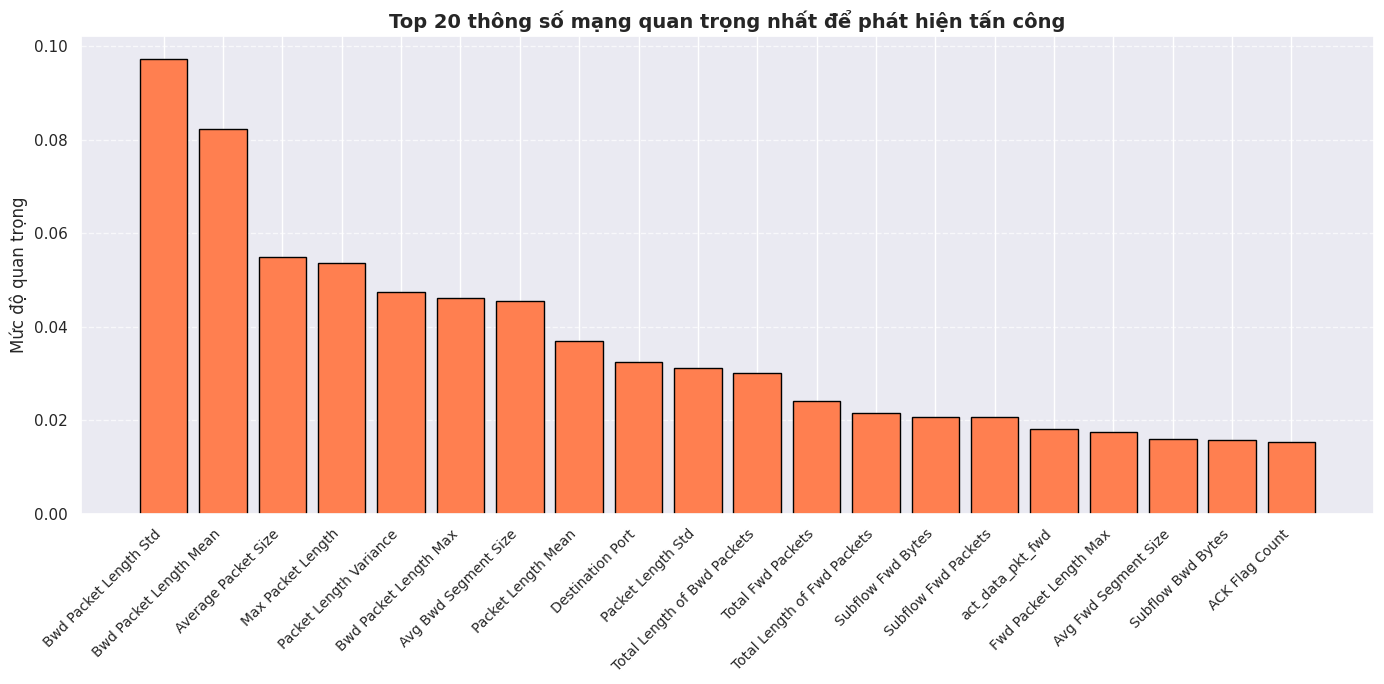

In [6]:
## Trích xuất điểm số từ mô hình đã huấn luyện
importances = forest.feature_importances_
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
## Lấy 20 đặc trưng có điểm cao nhất
top_20_features = feature_df.sort_values(by='Importance', ascending=False).head(20)
print(top_20_features.reset_index(drop=True))
## Vẽ biểu đồ
plt.figure(figsize=(14, 7))
plt.bar(top_20_features['Feature'], top_20_features['Importance'], color='coral', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Top 20 thông số mạng quan trọng nhất để phát hiện tấn công', fontsize=14, fontweight='bold')
plt.ylabel('Mức độ quan trọng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
## Lấy danh sách tên của 20 cột tốt nhất
best_features_list = top_20_features['Feature'].tolist()
## Tạo dataframe mới chỉ chứa 20 cột này và cột Nhãn cuối cùng
df_optimal = df[best_features_list + [label_column_name]]
# Đường dẫn lưu file
optimal_path = '/content/drive/MyDrive/BTL_TSL_MR/optimal_data.csv'
df_optimal.to_csv(optimal_path, index=False)
print(f"Lưu thành công tập dữ liệu tối ưu (chỉ còn {df_optimal.shape[1]} cột) tại: {optimal_path}")

Lưu thành công tập dữ liệu tối ưu (chỉ còn 21 cột) tại: /content/drive/MyDrive/BTL_TSL_MR/optimal_data.csv
